Ce notebook étudie et analyse la convergence du pricing d'option par arbre binomial vers la solution de l'équation de Black-Scholes

In [3]:
import numpy as np
from binomial.tree import eu_opt_pricing
from binomial.blackscholes import black_scholes_price
import matplotlib.pyplot as plt

In [21]:
# paramètres de l'option
sig=0.2
r=0.05
T=20
S0=50
K=45

In [ ]:
def erreur(bs,sig,r,T,S0,K,dt,option_type='call'):
    N = int(round(T/dt))
    binomial_price = eu_opt_pricing(sig, r, T, dt, S0, K, option_type=option_type)
    erreur = np.abs(binomial_price - bs)
    return N, erreur

In [49]:
def plot_erreur(sig,r,T,S0,K,option_type='call'):
    absc, errors=[],[]
    i=0
    bs_price=black_scholes_price(sig, r, T, S0, K, option_type=option_type)
    for N in np.arange(10, 1000, 5):
        dt=T/N
        N, err = erreur(bs_price, sig, r, T, S0, K, dt, option_type=option_type)
        absc.append(N)
        errors.append(err)
    absc = np.array(absc)
    errors = np.array(errors)
    pairs = absc % 2 == 0

    plt.loglog(absc, errors)
    plt.xlabel('N')
    plt.ylabel('|CRR − BS|')
    plt.legend()


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_12552\980504373.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


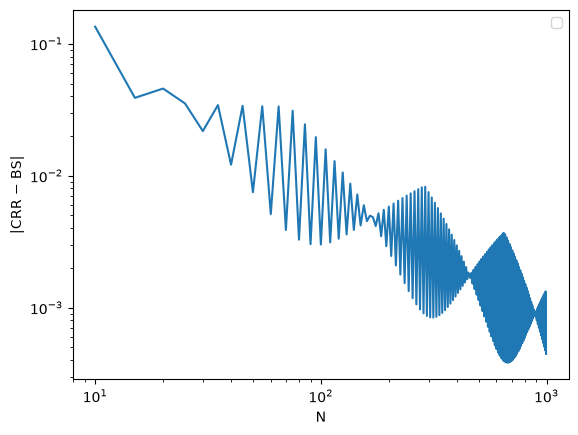

In [51]:
plot_erreur(sig,r,T,S0,K,option_type='call')

On observe deux phénomènes:
 - Un phénomène d'oscillation
 - Un effet "noeud papillon"

Essayons d'analyser et expliquer ces phénomènes

Une première piste est de tracer la droite en 1/N:

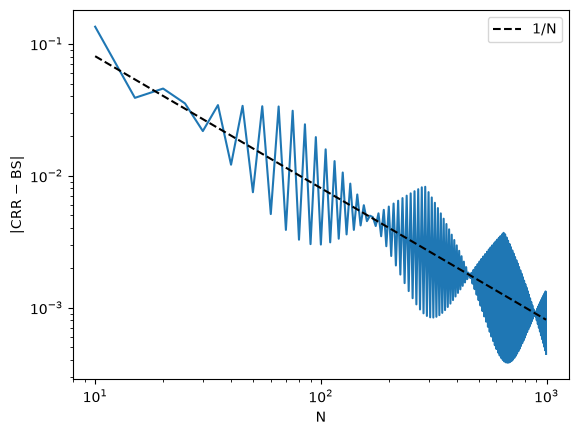

In [55]:
def plot_erreur(sig,r,T,S0,K,option_type='call'):
    absc, errors=[],[]
    i=0
    bs_price=black_scholes_price(sig, r, T, S0, K, option_type=option_type)
    for N in np.arange(10, 1000, 5):
        dt=T/N
        N, err = erreur(bs_price, sig, r, T, S0, K, dt, option_type=option_type)
        absc.append(N)
        errors.append(err)
    absc = np.array(absc)
    errors = np.array(errors)
    pairs = absc % 2 == 0

    plt.loglog(absc, errors)
    plt.xlabel('N')
    plt.ylabel('|CRR − BS|')
    Ns = np.array(absc)
    c = np.median(np.array(errors) * Ns)   # constante d'ancrage
    plt.loglog(Ns, c / Ns, 'k--', label='1/N')
    plt.legend()
plot_erreur(sig,r,T,S0,K,option_type='call')


In [52]:

def plot_parité(sig,r,T,S0,K,option_type='call'):
    absc, errors=[],[]
    i=0
    bs_price=black_scholes_price(sig, r, T, S0, K, option_type=option_type)
    for N in np.arange(10, 1000, 5):
        dt=T/N
        N, err = erreur(bs_price, sig, r, T, S0, K, dt, option_type=option_type)
        absc.append(N)
        errors.append(err)
    absc = np.array(absc)
    errors = np.array(errors)
    pairs = absc % 2 == 0

    plt.loglog(absc[pairs], errors[pairs], '.', label='N pair')
    plt.loglog(absc[~pairs], errors[~pairs], '.', label='N impair')
    plt.xlabel('N')
    plt.ylabel('|CRR − BS|')
    plt.legend()


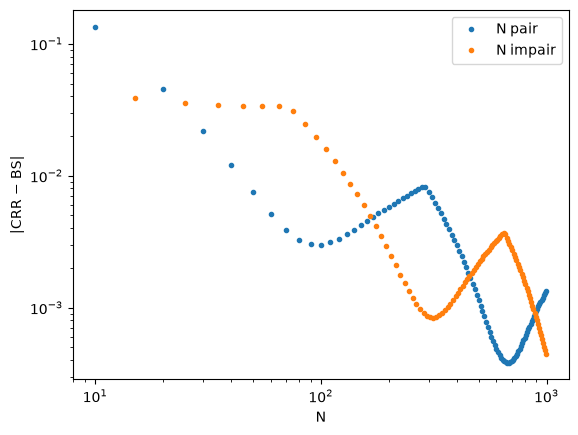

In [53]:
plot_parité(sig,r,T,S0,K,option_type='call')
